<a href="https://colab.research.google.com/github/jiffy-jacob/Assignments/blob/main/code_challenge3_and4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

You are given the Diamonds dataset from the seaborn library. Using only
NumPy and Pandas, perform the following tasks.
1. Load the Diamonds dataset using seaborn.
2. Store it in a Pandas DataFrame named df.
Create a new DataFrame named premium_df that satisfies all the following
conditions:
- cut is either "Ideal" or "Premium"
- color belongs to D, E, or F
- clarity belongs to VS1, VS2, or IF
- carat is greater than the median carat of the dataset
- price is greater than the mean price of the dataset

Using premium_df, create the following new columns:
1. price_per_carat = price / carat
2. volume = x × y × z
3. value_score = Min–Max normalized price_per_carat
4. log_price = natural logarithm of price

Using premium_df, create:
1. A scatter plot between carat and price, colored by cut
2. A scatter plot between volume and price_per_carat, colored by
clarity
3. A pair plot for:
- carat
- price
- price_per_carat
- value_score

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load dataset
data=sns.load_dataset('diamonds')
df=pd.DataFrame(data)
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
premium_df=df[(df['cut'].isin(['Ideal','Premium'])) &
              (df['color'].isin(['D','E','F'])) &
              (df['clarity'].isin(['VS1','VS2','IF'])) &
              (df['carat']>df['carat'].median()) &
              (df['price']>df['price'].mean())].copy()
premium_df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
5907,0.81,Ideal,F,VS1,61.5,55.0,3933,6.01,5.96,3.68
5917,0.73,Ideal,D,VS1,60.9,55.0,3937,5.83,5.86,3.56
5946,0.72,Ideal,E,VS1,61.1,57.0,3947,5.78,5.81,3.54
5975,0.72,Premium,E,IF,61.3,60.0,3951,5.74,5.71,3.51
5986,0.80,Ideal,F,VS1,61.6,54.0,3953,5.95,5.99,3.68


In [5]:
len(premium_df)

1390

In [6]:
premium_df.shape

(1390, 10)

In [7]:
df.shape

(53940, 10)

In [11]:
#price_per_carat = price / carat
premium_df['price_per_carat']=premium_df['price']/premium_df['carat']
#volume = x × y × z
premium_df['volume']=premium_df['x']*premium_df['y']*premium_df['z']
#value_score = Min–Max normalized price_per_carat
premium_df['value_score']=(premium_df['price_per_carat']-premium_df['price_per_carat'].min())/(premium_df['price_per_carat'].max()-premium_df['price_per_carat'].min())
#log_price=natural logarithm of price
premium_df['log_price']=np.log(premium_df['price'])
premium_df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_per_carat,volume,value_score,log_price
5907,0.81,Ideal,F,VS1,61.5,55.0,3933,6.01,5.96,3.68,4855.555556,131.816128,0.029782,8.277158
5917,0.73,Ideal,D,VS1,60.9,55.0,3937,5.83,5.86,3.56,5393.150685,121.623128,0.072438,8.278174
5946,0.72,Ideal,E,VS1,61.1,57.0,3947,5.78,5.81,3.54,5481.944444,118.879572,0.079483,8.280711
5975,0.72,Premium,E,IF,61.3,60.0,3951,5.74,5.71,3.51,5487.500000,115.041654,0.079924,8.281724
5986,0.80,Ideal,F,VS1,61.6,54.0,3953,5.95,5.99,3.68,4941.250000,131.157040,0.036581,8.282230


In [12]:
premium_df.shape

(1390, 14)

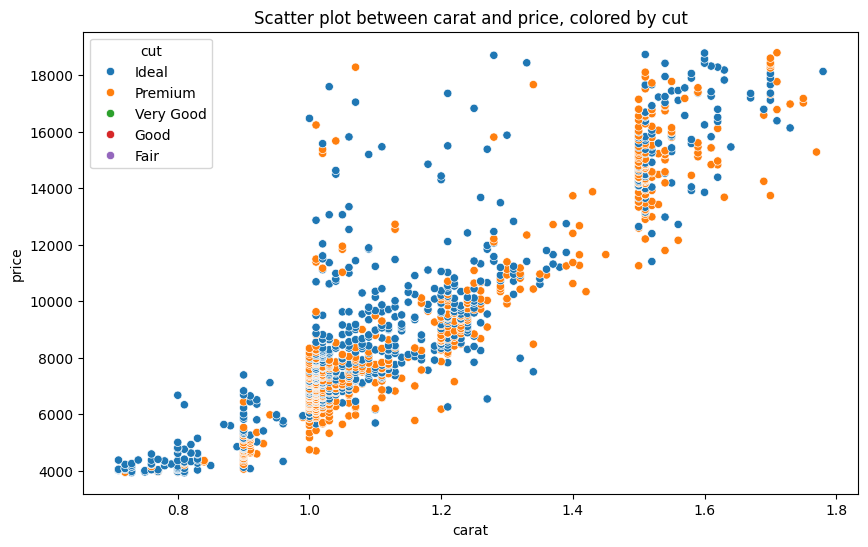

In [13]:
#Using premium_df, create a scatter plot between carat and price, colored by cut
plt.figure(figsize=(10,6))
sns.scatterplot(x='carat',y='price',hue='cut',data=premium_df)
plt.title('Scatter plot between carat and price, colored by cut')
plt.show()

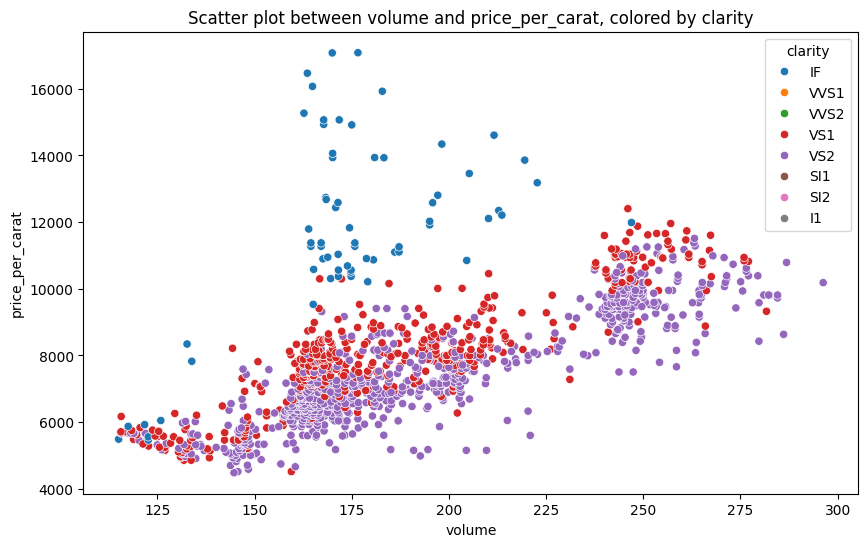

In [15]:
#A scatter plot between volume and price_per_carat, colored by clarity
plt.figure(figsize=(10,6))
sns.scatterplot(x='volume',y='price_per_carat',hue='clarity',data=premium_df)
plt.title('Scatter plot between volume and price_per_carat, colored by clarity')
plt.show()

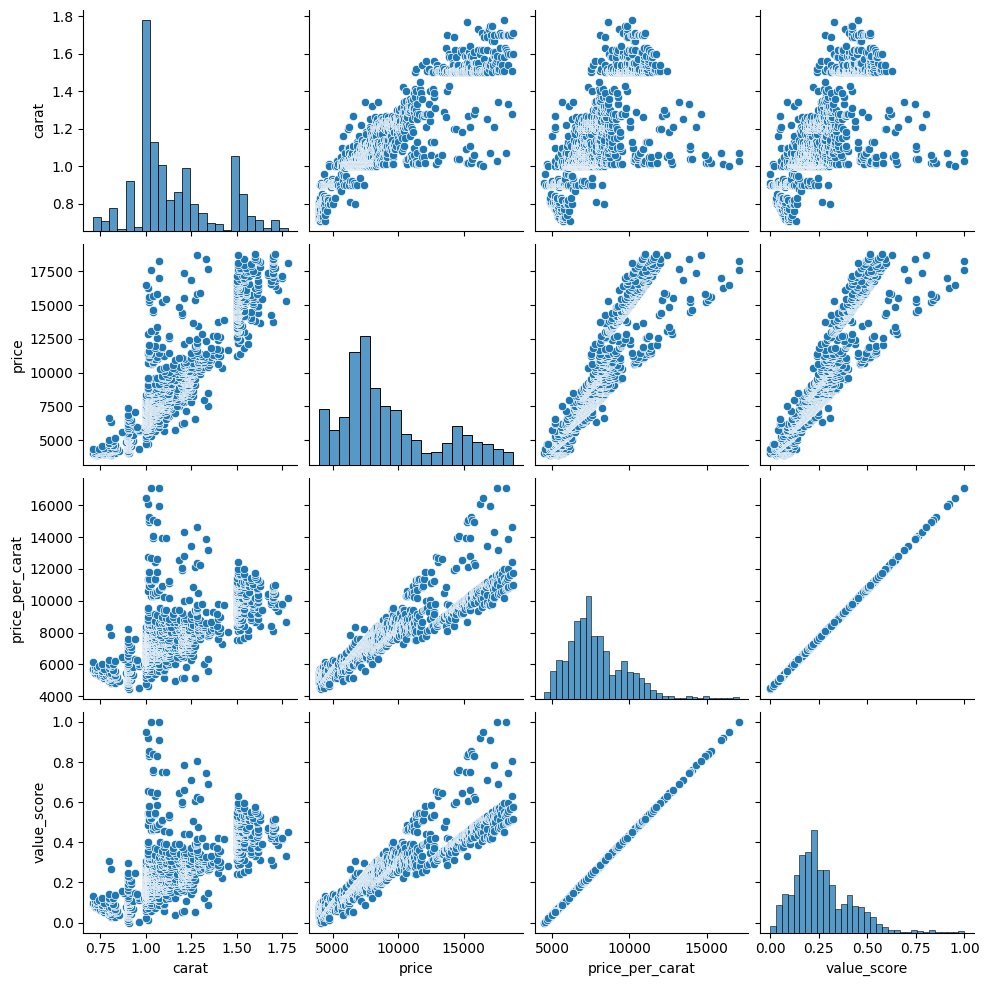

In [16]:
#  Create a pair plot for carat, price, price_per_carat, value_score
sns.pairplot(premium_df,vars=['carat','price','price_per_carat','value_score'])
plt.show()
